In [48]:
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [50]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [51]:
master_df = pd.read_csv("raw_data/master.csv")
master_df.head()

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,STATE,ZIP CODE,REGION,COUNTY,COUNTRY,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,FRACT OWNER,AIR WORTH DATE,OTHER NAMES(1),OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX,Unnamed: 34
0,100,5334,7100510,17003,1940,1,BENE MARY D,PO BOX 329,,KETCHUM,OK,743490329,2,097,US,20230122,20050506,1,4,1,V,50002263,,19540430,,,,,,20270430,600060,,,A004B3,NaN
1,10000,10000,2130004,,,7,9AT LLC,511 WEDGEWOOD AVE,,NASHVILLE,TN,372035521,3,037,US,20240823,20240823,,4,1,V,50003445,,,,,,,,20310831,1443200,,,A00725,NaN
2,10001,A28,9601202,67007,1928,1,STOOS ROBERT A,PO BOX 1056,,LAKELAND,FL,338021056,7,105,US,20230718,20190227,1,4,1,V,50003446,,,,,,,,20290228,432072,,,A00726,NaN
3,10004,T18208245,2072738,,,7,ETOS AIR LLC,PO BOX 288,,NEW LONDON,TX,756820288,2,401,US,20230722,20130312,,4,2,V,50003451,,,,,,,,20290331,102879,,,A00729,NaN
4,10006,BG-72,1152020,17026,1955,1,COUTCHES ROBERT HERCULES DBA,550 AIRWAY BLVD,,LIVERMORE,CA,945519533,4,001,US,20230421,19980826,1U,4,1,V,50003453,,19710909,AERO FLIGHT AVIATION,,,,,20280229,480110,,,A0072B,NaN


In [52]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309478 entries, 0 to 309477
Data columns (total 35 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   N-NUMBER          309478 non-null  str    
 1   SERIAL NUMBER     309478 non-null  str    
 2   MFR MDL CODE      309478 non-null  str    
 3   ENG MFR MDL       309478 non-null  str    
 4   YEAR MFR          309478 non-null  str    
 5   TYPE REGISTRANT   309478 non-null  str    
 6   NAME              309478 non-null  str    
 7   STREET            309478 non-null  str    
 8   STREET2           309478 non-null  str    
 9   CITY              309478 non-null  str    
 10  STATE             309478 non-null  str    
 11  ZIP CODE          309478 non-null  str    
 12  REGION            309478 non-null  str    
 13  COUNTY            309478 non-null  str    
 14  COUNTRY           309478 non-null  str    
 15  LAST ACTION DATE  309478 non-null  int64  
 16  CERT ISSUE DATE   309478 non-nu

## Entire Dataset Cleaning
- Strip leading and trailing whitespace (for all columns, except `CERTIFICATION`, which is treated specially)
- Drop empty unnamed column
- Convert date columns to datetime objects

In [53]:
date_subset = master_df[['LAST ACTION DATE', 'CERT ISSUE DATE', 'AIR WORTH DATE', 'EXPIRATION DATE']]

print(date_subset.head(10)) # all dates are formatted as yyyymmdd

   LAST ACTION DATE CERT ISSUE DATE AIR WORTH DATE EXPIRATION DATE
0          20230122        20050506       19540430        20270430
1          20240823        20240823                       20310831
2          20230718        20190227                       20290228
3          20230722        20130312                       20290331
4          20230421        19980826       19710909        20280229
5          20230707        20190102       19670128        20290131
6          20230825        20100211       19790809        20290831
7          20230505        20210414       19790427        20280430
8          20230718        20160216       20160219        20290228
9          20250707        20250707       20250710        20320731


In [54]:
# Clean column names by stripping whitespace
master_df.columns = master_df.columns.str.strip()

# Identify all object (string) columns
df_obj_cols = master_df.select_dtypes(['object']).columns

# Create a list of columns to strip by excluding 'CERTIFICATION'
# This safely handles cases where 'CERTIFICATION' might not exist
cols_to_strip = df_obj_cols.difference(['CERTIFICATION'])

# Apply stripping only to the filtered list
master_df[cols_to_strip] = master_df[cols_to_strip].apply(lambda x: x.astype(str).str.strip())

# Drop the empty column created due to a trailing comma in the CSV header
if 'Unnamed: 34' in master_df.columns:
    master_df = master_df.drop(columns=['Unnamed: 34'])

# Convert date columns (YYYYMMDD) to proper datetime objects
date_cols = ['LAST ACTION DATE', 'CERT ISSUE DATE', 'AIR WORTH DATE', 'EXPIRATION DATE']
for col in date_cols:
    if col in master_df.columns:
        master_df[col] = pd.to_datetime(master_df[col], format='%Y%m%d', errors='coerce')

master_df.head()

/var/folders/r5/7sdqfmvs4p987n2g0n_nng840000gn/T/ipykernel_89179/2328634412.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_obj_cols = master_df.select_dtypes(['object']).columns


,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,STATE,ZIP CODE,REGION,COUNTY,COUNTRY,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,FRACT OWNER,AIR WORTH DATE,OTHER NAMES(1),OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX
0,100,5334,7100510,17003,1940,1,BENE MARY D,PO BOX 329,,KETCHUM,OK,743490329,2,097,US,2023-01-22,2005-05-06,1,4,1,V,50002263,,1954-04-30,,,,,,2027-04-30,600060,,,A004B3
1,10000,10000,2130004,,,7,9AT LLC,511 WEDGEWOOD AVE,,NASHVILLE,TN,372035521,3,037,US,2024-08-23,2024-08-23,,4,1,V,50003445,,NaT,,,,,,2031-08-31,1443200,,,A00725
2,10001,A28,9601202,67007,1928,1,STOOS ROBERT A,PO BOX 1056,,LAKELAND,FL,338021056,7,105,US,2023-07-18,2019-02-27,1,4,1,V,50003446,,NaT,,,,,,2029-02-28,432072,,,A00726
3,10004,T18208245,2072738,,,7,ETOS AIR LLC,PO BOX 288,,NEW LONDON,TX,756820288,2,401,US,2023-07-22,2013-03-12,,4,2,V,50003451,,NaT,,,,,,2029-03-31,102879,,,A00729
4,10006,BG-72,1152020,17026,1955,1,COUTCHES ROBERT HERCULES DBA,550 AIRWAY BLVD,,LIVERMORE,CA,945519533,4,001,US,2023-04-21,1998-08-26,1U,4,1,V,50003453,,1971-09-09,AERO FLIGHT AVIATION,,,,,2028-02-29,480110,,,A0072B


In [55]:
cols_to_fix = master_df.columns.difference(['CERTIFICATION'])

# Replace empty/whitespace strings with NaN only in those columns
master_df[cols_to_fix] = master_df[cols_to_fix].replace(r'^\s*$', np.nan, regex=True)

## Cleaning `N-Number` column
- Ensure that all N-numbers are unique
- Prepend 'N-' to all N-numbers (the standard form)
- Ensure that all N-numbers are uppercase

In [56]:
# Ensure all N-numbers are unique
master_df['N-NUMBER'].is_unique

True

In [57]:
master_df['N-NUMBER'] = master_df['N-NUMBER'].str.upper().str.strip()
master_df['N-NUMBER'] = master_df['N-NUMBER'].apply(lambda x: 'N' + x if not x.startswith('N') else x)

In [58]:
master_df['N-NUMBER']

0           N100
1         N10000
2         N10001
3         N10004
4         N10006
           ...  
309473      N9ZS
309474      N9ZT
309475      N9ZU
309476      N9ZV
309477      N9ZX
Name: N-NUMBER, Length: 309478, dtype: str

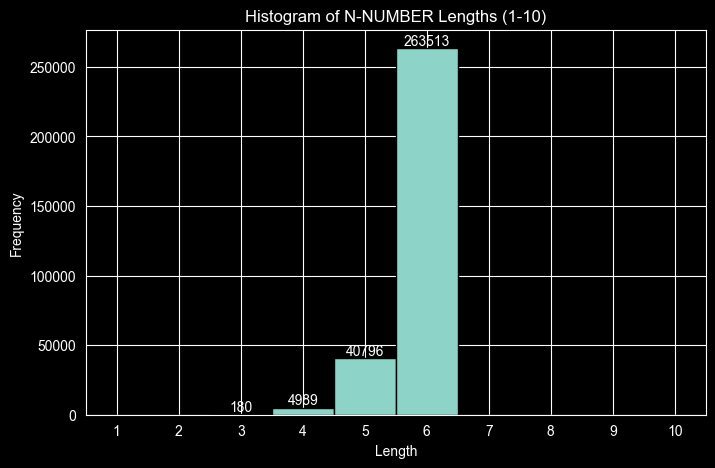

In [59]:
# Calculate lengths
lengths = master_df['N-NUMBER'].astype(str).str.len()

# Keep only lengths 1-10
lengths = lengths[(lengths >= 1) & (lengths <= 10)]

# Define integer-centered bins
bins = np.arange(1, 12) - 0.5

plt.figure(figsize=(8, 5))#
counts, bin_edges, patches = plt.hist(lengths, bins=bins, edgecolor='black')

# Add labels for non-zero bars
for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, int(count), 
                 ha='center', va='bottom')

plt.xticks(range(1, 11))
plt.xlim(0.5, 10.5)

plt.title('Histogram of N-NUMBER Lengths (1-10)')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.show()

## Cleaning `SERIAL NUMBER` column
- Ensuring no empty string or null values

In [60]:
master_df['SERIAL NUMBER'].value_counts()

SERIAL NUMBER
001             1758
1                906
002              250
0001             176
01               162
                ... 
501-0047           1
Z610204TUEXP       1
L2K-106            1
SB3                1
18-7028            1
Name: count, Length: 242301, dtype: int64

In [61]:
print(master_df['SERIAL NUMBER'].isna().sum())
print(master_df['SERIAL NUMBER'].eq('').sum())
print(master_df['SERIAL NUMBER'].eq(' ').sum())

0
0
0


In [62]:
acftref = pd.read_csv('raw_data/ACFTREF.csv')
acftref.head()

,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,Unnamed: 13
0,0020901,AAR AIRLIFT GROUP INC,UH-60A,6,3,1,0,2,15,CLASS 3,0,,,NaN
1,0030109,EXLINE ACE-C,ACE-C,4,1,1,1,1,1,CLASS 1,82,,,NaN
2,003010D,DELEBAUGH,P,4,1,1,1,1,1,CLASS 1,82,,,NaN
3,003010H,DAL PORTO,BABY ACE D,4,1,1,1,1,1,CLASS 1,82,,,NaN
4,003010P,DUNN,BABY ACE,4,1,1,1,1,1,CLASS 1,82,,,NaN


## Cleaning `MFR MDL CODE` column
- Ensure none are empty string or null values

In [63]:
print(master_df['MFR MDL CODE'].isna().sum())
print(master_df['MFR MDL CODE'].eq('').sum())
print(master_df['MFR MDL CODE'].eq(' ').sum())

0
0
0


## Cleaning `YEAR_MFR` column
- There are rows with both empty string "" and "0000" for this column, so we will replace all "0000" with empty string "".

In [64]:
master_df['YEAR MFR'].value_counts().sort_index()

YEAR MFR
0000     150
1909       1
1910       2
1911       1
1912       1
        ... 
2022    3339
2023    3873
2024    3810
2025    3501
2026      52
Name: count, Length: 116, dtype: int64

In [65]:
master_df.loc[master_df['YEAR MFR'] == '0000', 'YEAR MFR'] = np.nan

In [66]:
# change YEAR MFR to float (since contains NaN, which can only be floats)
master_df['YEAR MFR'] = master_df['YEAR MFR'].astype('Int64')


In [67]:
master_df[master_df['YEAR MFR'].isna()]

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,STATE,ZIP CODE,REGION,COUNTY,COUNTRY,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,FRACT OWNER,AIR WORTH DATE,OTHER NAMES(1),OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX
1,N10000,10000,2130004,NaN,<NA>,7,9AT LLC,511 WEDGEWOOD AVE,NaN,NASHVILLE,TN,372035521,3,037,US,2024-08-23,2024-08-23,,4,1,V,50003445,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2031-08-31,1443200,NaN,NaN,A00725
3,N10004,T18208245,2072738,NaN,<NA>,7,ETOS AIR LLC,PO BOX 288,NaN,NEW LONDON,TX,756820288,2,401,US,2023-07-22,2013-03-12,,4,2,V,50003451,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-03-31,102879,NaN,NaN,A00729
13,N1000M,108-3741,9230408,27025,<NA>,4,VALDEZ RAYMOND G,1702 NEW MEXICO AVE,NaN,LAS VEGAS,NM,877013711,2,047,US,2023-10-15,2023-10-15,1,4,1,V,50003430,NaN,1956-06-23,VALDEZ REBECCA A,NaN,NaN,NaN,NaN,2030-10-31,310110,NaN,NaN,A00718
16,N1000Q,310P0195,2074238,17027,<NA>,4,ERNEST OBREGON,2910 VINE HILL RD,NaN,OAKLEY,CA,945611739,4,013,US,2023-07-22,2022-03-19,1N,5,1,V,50003433,NaN,1970-05-18,IRIS A OBREGON,NaN,NaN,NaN,NaN,2029-03-31,280110,NaN,NaN,A0071B
17,N1000R,1732,4690506,52008,<NA>,1,LARMON LARRY V,661 COVERED WAGON TRL,NaN,VALPARAISO,IN,463839771,C,127,US,2023-04-13,2023-04-13,1,4,1,V,50003434,NaN,1958-10-31,NaN,NaN,NaN,NaN,NaN,2030-04-30,270110,NaN,NaN,A0071C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309445,N9XS,A123,056139I,99999,<NA>,1,JOHNSON DAVID B,1713 WOODSON DR,NaN,KNOXVILLE,TN,379203857,3,093,US,2023-10-13,2020-03-25,42,1,1,V,53066230,NaN,2002-06-08,NaN,NaN,NaN,NaN,NaN,2030-03-31,313986,EUROPA AIRCRAFT,EUROPA MOTORGLIDER,AC6C98
309457,N9YM,T18208459,2072738,41533,<NA>,7,SCENIC AVIATION LLC,601 SHEKEL LN,NaN,BRECKENRIDGE,CO,804248931,S,117,US,2023-09-22,2022-12-22,1N,4,2,V,53066254,NaN,2005-11-25,NaN,NaN,NaN,NaN,NaN,2029-12-31,194309,NaN,NaN,AC6CAC
309460,N9YS,562648112,056177N,NaN,<NA>,3,AIR FLIGHT ENTERPRISES INC,2430 S NOVA RD,NaN,SOUTH DAYTONA,FL,321198838,7,127,US,2023-05-12,2018-05-08,,6,3,V,53066261,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2028-05-31,132109,NaN,NaN,AC6CB1
309472,N9ZR,2228,8680511,60020,<NA>,3,INTERNATIONAL AIR SERVICES INC TRUSTEE,123 W NYE LN STE 129,NaN,CARSON CITY,NV,897060838,4,510,US,2025-05-08,2025-05-08,1,6,3,V,53066311,NaN,1993-10-21,NaN,NaN,NaN,NaN,NaN,2032-05-31,183334,NaN,NaN,AC6CC9


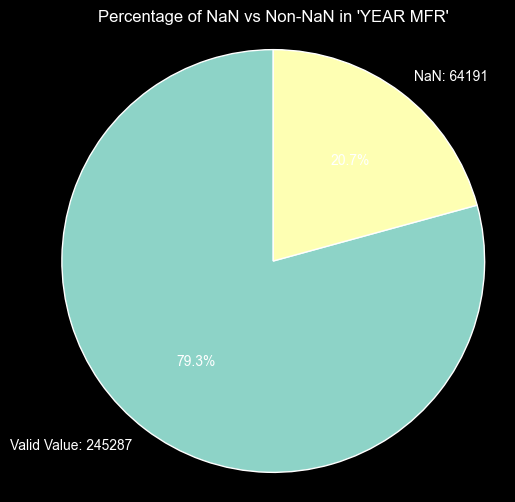

In [68]:
nan_count = master_df['YEAR MFR'].isna().sum()
non_nan_count = master_df['YEAR MFR'].notna().sum()

# Data for pie chart
labels = ['Valid Value: ' + str(non_nan_count) , 'NaN: ' + str(nan_count)]
sizes = [non_nan_count, nan_count]

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Percentage of NaN vs Non-NaN in 'YEAR MFR'")
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.show()

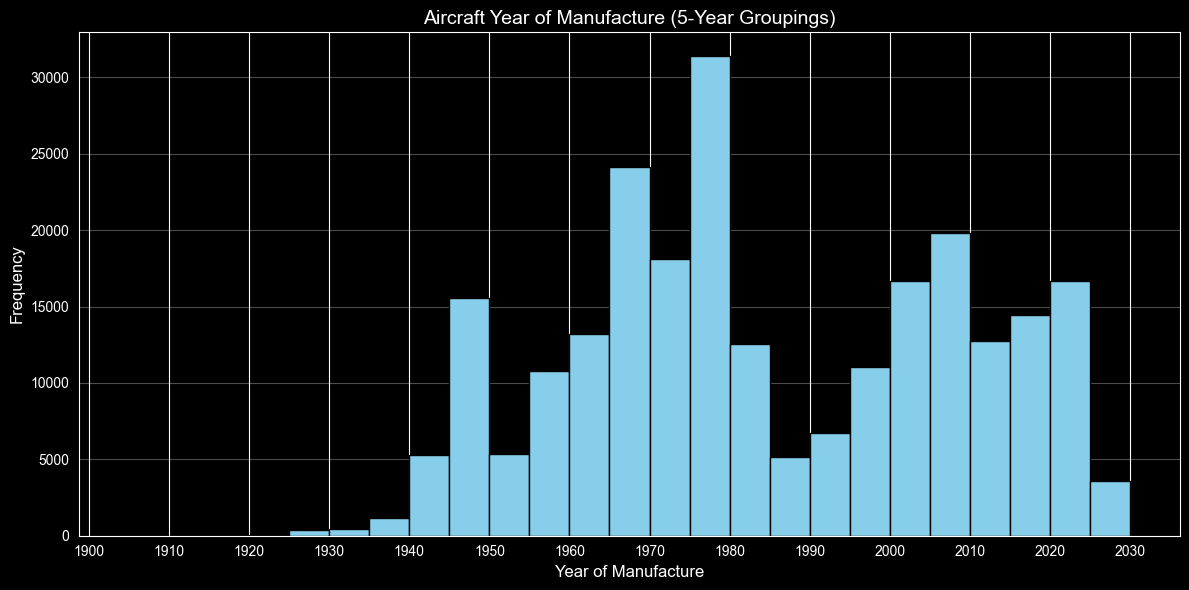

In [69]:
# Adjustable variables
bin_size = 5 # controls the width of the bars
tick_interval = 10   # controls how often x-axis labels appear

min_year = int(master_df['YEAR MFR'].min())
max_year = int(master_df['YEAR MFR'].max())

bins = np.arange(
    (min_year // bin_size) * bin_size,
    ((max_year // bin_size) + 2) * bin_size,
    bin_size
)

plt.figure(figsize=(12, 6))
master_df['YEAR MFR'].hist(bins=bins, edgecolor='black', color='skyblue')

plt.title(f'Aircraft Year of Manufacture ({bin_size}-Year Groupings)', fontsize=14)
plt.xlabel('Year of Manufacture', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Fewer x-axis labels
tick_range = np.arange(
    (min_year // tick_interval) * tick_interval,
    max_year + tick_interval,
    tick_interval
)
plt.xticks(tick_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
master_df['YEAR MFR'].value_counts(dropna=False).sort_index()

YEAR MFR
1909        1
1910        2
1911        1
1912        1
1913        1
        ...  
2023     3873
2024     3810
2025     3501
2026       52
<NA>    64191
Name: count, Length: 116, dtype: Int64

## Cleaning "TYPE REGISTRANT" column
- Replacing numeric codes from 1-9 with their descriptions, taken from the FAA website.
- Keep empty values as np.nan

In [71]:
master_df['TYPE REGISTRANT'].value_counts(dropna=False).sort_index()

TYPE REGISTRANT
1      129522
2        3148
3       58810
4       26105
5        5608
7       83897
8        1947
9          17
NaN       424
Name: count, dtype: int64

In [72]:
type_registrant_map = {
    '1': 'Individual',
    '2': 'Partnership',
    '3': 'Corporation',
    '4': 'Co-Owned',
    '5': 'Government',
    '7': 'LLC',
    '8': 'Non Citizen Corporation',
    '9': 'Non Citizen Co-Owned'
}

master_df['TYPE REGISTRANT'] = master_df['TYPE REGISTRANT'].map(type_registrant_map)

In [73]:
master_df

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,STATE,ZIP CODE,REGION,COUNTY,COUNTRY,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,FRACT OWNER,AIR WORTH DATE,OTHER NAMES(1),OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX
0,N100,5334,7100510,17003,1940,Individual,BENE MARY D,PO BOX 329,NaN,KETCHUM,OK,743490329,2,097,US,2023-01-22,2005-05-06,1,4,1,V,50002263,NaN,1954-04-30,NaN,NaN,NaN,NaN,NaN,2027-04-30,600060,NaN,NaN,A004B3
1,N10000,10000,2130004,NaN,<NA>,LLC,9AT LLC,511 WEDGEWOOD AVE,NaN,NASHVILLE,TN,372035521,3,037,US,2024-08-23,2024-08-23,,4,1,V,50003445,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2031-08-31,1443200,NaN,NaN,A00725
2,N10001,A28,9601202,67007,1928,Individual,STOOS ROBERT A,PO BOX 1056,NaN,LAKELAND,FL,338021056,7,105,US,2023-07-18,2019-02-27,1,4,1,V,50003446,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-02-28,432072,NaN,NaN,A00726
3,N10004,T18208245,2072738,NaN,<NA>,LLC,ETOS AIR LLC,PO BOX 288,NaN,NEW LONDON,TX,756820288,2,401,US,2023-07-22,2013-03-12,,4,2,V,50003451,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-03-31,102879,NaN,NaN,A00729
4,N10006,BG-72,1152020,17026,1955,Individual,COUTCHES ROBERT HERCULES DBA,550 AIRWAY BLVD,NaN,LIVERMORE,CA,945519533,4,001,US,2023-04-21,1998-08-26,1U,4,1,V,50003453,NaN,1971-09-09,AERO FLIGHT AVIATION,NaN,NaN,NaN,NaN,2028-02-29,480110,NaN,NaN,A0072B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309473,N9ZS,20004,5760102,00000,1974,Individual,COLLINS BRIAN D,42 BOGART DR,NaN,PETERSBURG,WV,268478166,1,023,US,2023-06-03,1996-09-23,1G,1,0,V,53066312,NaN,1976-03-12,NaN,NaN,NaN,NaN,NaN,2028-08-31,221481,NaN,NaN,AC6CCA
309474,N9ZT,0088,2130001,17042,2001,LLC,VALIAIR LC TRUSTEE,OGDEN AIRPORT GATEWAY CENTER,4248 S 1650 W BLDG 1 STE 10,OGDEN,UT,84405,S,057,US,2024-09-10,2022-05-09,1N,4,1,V,53066313,NaN,2001-09-06,NaN,NaN,NaN,NaN,NaN,2029-05-31,233847,NaN,NaN,AC6CCB
309475,N9ZU,18-7028,7101828,41508,1959,Individual,FOWLER RONALD W,478 AIRPORT RD,NaN,LOPEZ ISLAND,WA,982618217,S,055,US,2023-04-01,2017-11-14,1N,4,1,V,53066314,NaN,2001-10-10,NaN,NaN,NaN,NaN,NaN,2027-11-30,264074,NaN,NaN,AC6CCC
309476,N9ZV,3793,1181511,03020,<NA>,LLC,L& R INVESTMENT PARTNERS LLC,1209 N ORANGE ST,NaN,WILMINGTON,DE,198011120,1,003,US,2025-07-26,2025-07-26,1N,6,3,V,53066315,NaN,2001-07-10,NaN,NaN,NaN,NaN,NaN,2032-07-31,281264,NaN,NaN,AC6CCD


In [74]:
master_df['TYPE REGISTRANT'].value_counts(dropna=False).sort_index()

TYPE REGISTRANT
Co-Owned                    26105
Corporation                 58810
Government                   5608
Individual                 129522
LLC                         83897
Non Citizen Co-Owned           17
Non Citizen Corporation      1947
Partnership                  3148
NaN                           424
Name: count, dtype: int64

In [75]:
master_df

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,STATE,ZIP CODE,REGION,COUNTY,COUNTRY,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,FRACT OWNER,AIR WORTH DATE,OTHER NAMES(1),OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX
0,N100,5334,7100510,17003,1940,Individual,BENE MARY D,PO BOX 329,NaN,KETCHUM,OK,743490329,2,097,US,2023-01-22,2005-05-06,1,4,1,V,50002263,NaN,1954-04-30,NaN,NaN,NaN,NaN,NaN,2027-04-30,600060,NaN,NaN,A004B3
1,N10000,10000,2130004,NaN,<NA>,LLC,9AT LLC,511 WEDGEWOOD AVE,NaN,NASHVILLE,TN,372035521,3,037,US,2024-08-23,2024-08-23,,4,1,V,50003445,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2031-08-31,1443200,NaN,NaN,A00725
2,N10001,A28,9601202,67007,1928,Individual,STOOS ROBERT A,PO BOX 1056,NaN,LAKELAND,FL,338021056,7,105,US,2023-07-18,2019-02-27,1,4,1,V,50003446,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-02-28,432072,NaN,NaN,A00726
3,N10004,T18208245,2072738,NaN,<NA>,LLC,ETOS AIR LLC,PO BOX 288,NaN,NEW LONDON,TX,756820288,2,401,US,2023-07-22,2013-03-12,,4,2,V,50003451,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-03-31,102879,NaN,NaN,A00729
4,N10006,BG-72,1152020,17026,1955,Individual,COUTCHES ROBERT HERCULES DBA,550 AIRWAY BLVD,NaN,LIVERMORE,CA,945519533,4,001,US,2023-04-21,1998-08-26,1U,4,1,V,50003453,NaN,1971-09-09,AERO FLIGHT AVIATION,NaN,NaN,NaN,NaN,2028-02-29,480110,NaN,NaN,A0072B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309473,N9ZS,20004,5760102,00000,1974,Individual,COLLINS BRIAN D,42 BOGART DR,NaN,PETERSBURG,WV,268478166,1,023,US,2023-06-03,1996-09-23,1G,1,0,V,53066312,NaN,1976-03-12,NaN,NaN,NaN,NaN,NaN,2028-08-31,221481,NaN,NaN,AC6CCA
309474,N9ZT,0088,2130001,17042,2001,LLC,VALIAIR LC TRUSTEE,OGDEN AIRPORT GATEWAY CENTER,4248 S 1650 W BLDG 1 STE 10,OGDEN,UT,84405,S,057,US,2024-09-10,2022-05-09,1N,4,1,V,53066313,NaN,2001-09-06,NaN,NaN,NaN,NaN,NaN,2029-05-31,233847,NaN,NaN,AC6CCB
309475,N9ZU,18-7028,7101828,41508,1959,Individual,FOWLER RONALD W,478 AIRPORT RD,NaN,LOPEZ ISLAND,WA,982618217,S,055,US,2023-04-01,2017-11-14,1N,4,1,V,53066314,NaN,2001-10-10,NaN,NaN,NaN,NaN,NaN,2027-11-30,264074,NaN,NaN,AC6CCC
309476,N9ZV,3793,1181511,03020,<NA>,LLC,L& R INVESTMENT PARTNERS LLC,1209 N ORANGE ST,NaN,WILMINGTON,DE,198011120,1,003,US,2025-07-26,2025-07-26,1N,6,3,V,53066315,NaN,2001-07-10,NaN,NaN,NaN,NaN,NaN,2032-07-31,281264,NaN,NaN,AC6CCD


## Cleaning `REGION` Column
- Replace region codes with their respective meanings

In [76]:
master_df['REGION'].value_counts(dropna=False)

REGION
2      47715
C      46402
S      45593
1      43429
4      39218
7      38040
3      27648
5       9083
E       8278
NaN     2839
8       1233
Name: count, dtype: int64

In [77]:
region_map = {
    '1': 'Eastern',
    '2': 'Southwestern',
    '3': 'Central',
    '4': 'Western-Pacific',
    '5': 'Alaskan',
    '7': 'Southern',
    '8': 'European',
    'C': 'Great Lakes',
    'E': 'New England',
    'S': 'Northwest Mountain'
}

master_df['REGION'] = master_df['REGION'].map(region_map)

# Verify the update
print(master_df['REGION'].value_counts(dropna=False))

REGION
Southwestern          47715
Great Lakes           46402
Northwest Mountain    45593
Eastern               43429
Western-Pacific       39218
Southern              38040
Central               27648
Alaskan                9083
New England            8278
NaN                    2839
European               1233
Name: count, dtype: int64


## Cleaning `Certification` column

In [78]:
master_df['CERTIFICATION'].value_counts()

CERTIFICATION
1N            97589
1             42214
1NU           31879
              30018
42            29519
              ...  
613145            1
6230              1
6232              1
1NUG              1
4027              1
Name: count, Length: 309, dtype: int64

In [79]:
master_df['CERTIFICATION'] = master_df['CERTIFICATION'].replace(r'^\s*$', np.nan, regex=True)

In [80]:
def decode_certification(cert_code):
    # Handle missing or empty values
    if pd.isna(cert_code) or not str(cert_code).strip():
        return pd.Series({'Airworthiness_Classification': np.nan, 'Approved_Operations': np.nan})
    
    # Ensure it's a string (pandas sometimes reads '42' as an integer)
    cert_code = str(cert_code).strip()
    
    # Position 238: Airworthiness Classification (1st character)
    airworthiness_class = cert_code[0]
    
    # Positions 239+: Approved Operations (remaining characters)
    ops_string = cert_code[1:]
    
    # --- Data Dictionary Mappings ---
    class_map = {
        '1': 'Standard', '2': 'Limited', '3': 'Restricted', 
        '4': 'Experimental', '5': 'Provisional', '6': 'Multiple', 
        '7': 'Primary', '8': 'Special Flight Permit', '9': 'Light Sport'
    }
    
    standard_map = {'N': 'Normal', 'U': 'Utility', 'A': 'Acrobatic', 'T': 'Transport', 'G': 'Glider', 'B': 'Balloon', 'C': 'Commuter', 'O': 'Other'}
    restricted_map = {'0': 'Other', '1': 'Agriculture and Pest Control', '2': 'Aerial Surveying', '3': 'Aerial Advertising', '4': 'Forest', '5': 'Patrolling', '6': 'Weather Control', '7': 'Carriage of Cargo'}
    experimental_map = {
        '0': 'To show compliance with FAR', '1': 'Research and Development', '2': 'Amateur Built', '3': 'Exhibition', '4': 'Racing', '5': 'Crew Training', 
        '6': 'Market Survey', '7': 'Operating Kit Built Aircraft', '8A': 'Reg. Prior to 01/31/08', '8B': 'Operating Light-Sport Kit-Built', 
        '8C': 'Operating Light-Sport Previously issued cert under 21.190', '9A': 'Unmanned Aircraft - Research and Development', 
        '9B': 'Unmanned Aircraft - Market Survey', '9C': 'Unmanned Aircraft - Crew Training', '9D': 'Unmanned Aircraft - Exhibition', '9E': 'Unmanned Aircraft - Compliance With CFR'
    }
    provisional_map = {'1': 'Class I', '2': 'Class II'}
    multiple_cert_map = {'1': 'Standard', '2': 'Limited', '3': 'Restricted'}
    special_map = {'1': 'Ferry flight for repairs, alterations, maintenance or storage', '2': 'Evacuate from area of impending danger', '3': 'Operation in excess of maximum certificated', '4': 'Delivery or export', '5': 'Production flight testing', '6': 'Customer Demo'}
    light_sport_map = {'A': 'Airplane', 'G': 'Glider', 'L': 'Lighter than Air', 'P': 'Power-Parachute', 'W': 'Weight-Shift-Control'}

    # Determine primary classification
    primary_class_name = class_map.get(airworthiness_class, f'Unknown({airworthiness_class})')
    ops_list = []
    
    # Parse operations based on primary classification rules
    if ops_string:
        if airworthiness_class == '1':
            ops_list = [standard_map.get(char, f'Unknown({char})') for char in ops_string]
        
        elif airworthiness_class == '3':
            ops_list = [restricted_map.get(char, f'Unknown({char})') for char in ops_string]
        
        elif airworthiness_class == '4':
            # Experimental has 2-character codes (like 8A, 9C), so we need to parse greedily
            i = 0
            while i < len(ops_string):
                if i + 1 < len(ops_string) and ops_string[i:i+2] in experimental_map:
                    ops_list.append(experimental_map[ops_string[i:i+2]])
                    i += 2
                else:
                    ops_list.append(experimental_map.get(ops_string[i], f'Unknown({ops_string[i]})'))
                    i += 1
                    
        elif airworthiness_class == '5':
            ops_list = [provisional_map.get(char, f'Unknown({char})') for char in ops_string]
            
        elif airworthiness_class == '6':
            # Multiple has cert codes in first two positions, restricted operations in the rest
            for i, char in enumerate(ops_string):
                if i < 2:
                    ops_list.append(f"Cert: {multiple_cert_map.get(char, f'Unknown({char})')}")
                else:
                    ops_list.append(restricted_map.get(char, f'Unknown({char})'))
                    
        elif airworthiness_class == '8':
            ops_list = [special_map.get(char, f'Unknown({char})') for char in ops_string]
            
        elif airworthiness_class == '9':
            ops_list = [light_sport_map.get(char, f'Unknown({char})') for char in ops_string]
            
        # Note: Classes 2 (Limited) and 7 (Primary) have blank operations records
            
    return pd.Series({
        'Airworthiness_Classification': primary_class_name,
        'Approved_Operations': ', '.join(ops_list) if ops_list else np.nan
    })

# Apply the function to create two new, clean columns
master_df[['Airworthiness_Classification', 'Approved_Operations']] = master_df['CERTIFICATION'].apply(decode_certification)

# View the result
print(master_df[['CERTIFICATION', 'Airworthiness_Classification', 'Approved_Operations']].head(10))

  CERTIFICATION Airworthiness_Classification           Approved_Operations
0    1                              Standard                           NaN
1           NaN                          NaN                           NaN
2    1                              Standard                           NaN
3           NaN                          NaN                           NaN
4    1U                             Standard                       Utility
5    1N                             Standard                        Normal
6    31                           Restricted  Agriculture and Pest Control
7    1G                             Standard                        Glider
8    1T                             Standard                     Transport
9    1B                             Standard                       Balloon


In [81]:
master_df['CERTIFICATION'] = master_df['CERTIFICATION'].str.strip()

## Cleaning `TYPE AIRCRAFT`, `TYPE ENGINE`, `STATUS CODE` columns
- Replace cryptic codes with their meaningful descriptions

In [82]:
# Define the mapping based on your requirements
aircraft_type_map = {
    '1': 'Glider',
    '2': 'Balloon',
    '3': 'Blimp/Dirigible',
    '4': 'Fixed wing single engine',
    '5': 'Fixed wing multi engine',
    '6': 'Rotorcraft',
    '7': 'Weight-shift-control',
    '8': 'Powered Parachute',
    '9': 'Gyroplane',
    'H': 'Hybrid Lift',
    'O': 'Other'
}

# Apply the mapping
# Using .astype(str) ensures that numeric codes are treated as strings to match the keys
master_df['TYPE AIRCRAFT'] = master_df['TYPE AIRCRAFT'].astype(str).map(aircraft_type_map)

# Check the results
print(master_df['TYPE AIRCRAFT'].value_counts())

TYPE AIRCRAFT
Fixed wing single engine    219797
Fixed wing multi engine      49126
Rotorcraft                   25805
Balloon                       5206
Glider                        4854
Powered Parachute             1904
Hybrid Lift                   1279
Weight-shift-control          1053
Gyroplane                      388
Blimp/Dirigible                 49
Other                           17
Name: count, dtype: int64


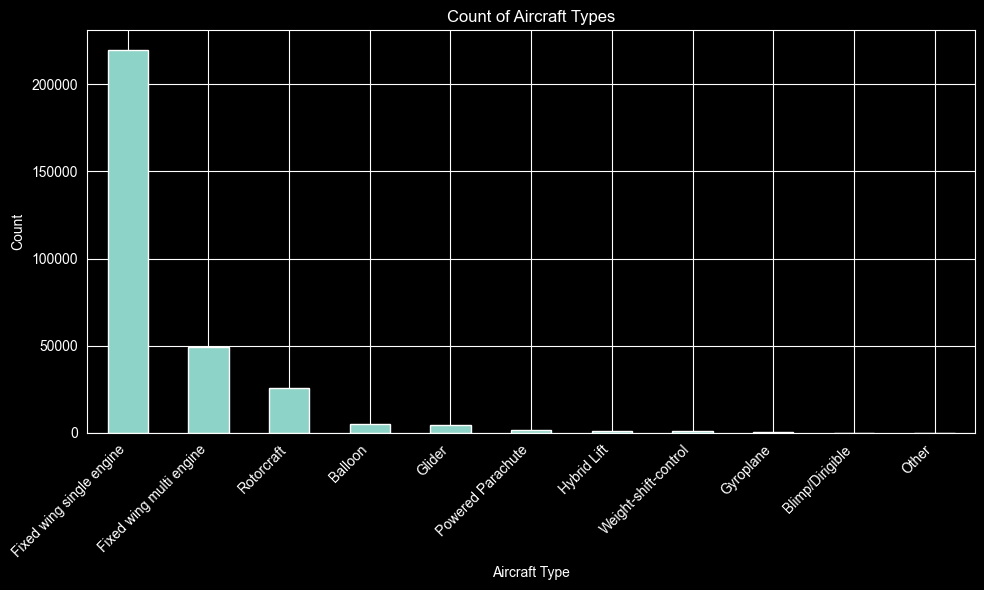

In [83]:
aircraft_counts = master_df['TYPE AIRCRAFT'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
aircraft_counts.plot(kind='bar')

plt.title('Count of Aircraft Types')
plt.xlabel('Aircraft Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [84]:
engine_type_map = {
    '0': 'None',
    '1': 'Reciprocating',
    '2': 'Turbo-prop',
    '3': 'Turbo-shaft',
    '4': 'Turbo-jet',
    '5': 'Turbo-fan',
    '6': 'Ramjet',
    '7': '2 Cycle',
    '8': '4 Cycle',
    '9': 'Unknown',
    '10': 'Electric',
    '11': 'Rotary'
}

master_df['TYPE ENGINE'] = master_df['TYPE ENGINE'].astype(str).map(engine_type_map)

In [85]:
print(master_df['TYPE ENGINE'].value_counts(dropna=False))

TYPE ENGINE
Reciprocating    209537
Turbo-fan         26860
4 Cycle           21329
Turbo-prop        13966
Electric          12444
Turbo-shaft        9652
None               9079
2 Cycle            4996
Turbo-jet          1529
Rotary               77
Unknown               5
Ramjet                4
Name: count, dtype: int64


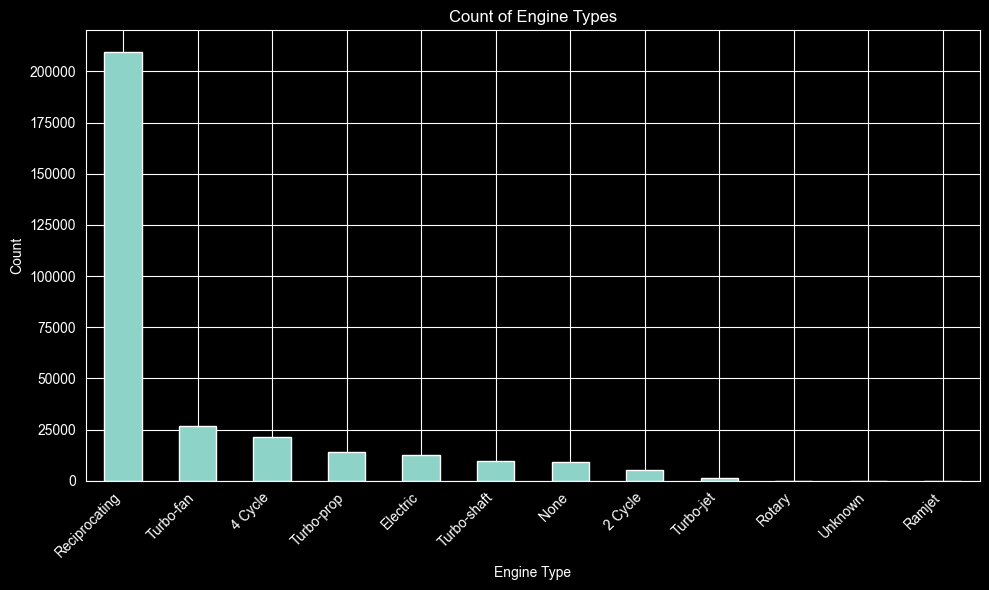

In [86]:
engine_counts = master_df['TYPE ENGINE'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
engine_counts.plot(kind='bar')

plt.title('Count of Engine Types')
plt.xlabel('Engine Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [87]:
status_code_map = {
    'A': 'Triennial form mailed, not returned',
    'D': 'Expired Dealer',
    'E': 'Registration revoked by enforcement',
    'M': 'Valid - Manufacturer Dealer Certificate',
    'N': 'Non-citizen Corp - no flight reports',
    'R': 'Registration pending',
    'S': 'Second Triennial form mailed, not returned',
    'T': 'Valid Registration (Trainee)',
    'V': 'Valid Registration',
    'W': 'Registration Ineffective or Invalid',
    'X': 'Enforcement Letter',
    'Z': 'Permanent Reserved',
    '1': 'Triennial form returned undeliverable',
    '2': 'N-Number Assigned - not registered',
    '3': 'N-Number assigned (Non Type Cert) - not registered',
    '4': 'N-Number assigned (Import) - not registered',
    '5': 'Reserved N-Number',
    '6': 'Administratively canceled',
    '7': 'Sale reported',
    '8': 'Second attempt Triennial form - no response',
    '9': 'Registration revoked',
    '10': 'N-Number assigned - pending cancellation',
    '11': 'N-Number assigned (Amateur) - pending cancellation',
    '12': 'N-Number assigned (Import) - pending cancellation',
    '13': 'Registration Expired',
    '14': 'First Notice for Re-Registration/Renewal',
    '15': 'Second Notice for Re-Registration/Renewal',
    '16': 'Registration Expired – Pending Cancellation',
    '17': 'Sale Reported – Pending Cancellation',
    '18': 'Sale Reported – Canceled',
    '19': 'Registration Pending – Pending Cancellation',
    '20': 'Registration Pending – Canceled',
    '21': 'Revoked – Pending Cancellation',
    '22': 'Revoked – Canceled',
    '23': 'Expired Dealer (Pending Cancellation)',
    '24': 'Third Notice for Re-Registration/Renewal',
    '25': 'First Notice for Registration Renewal',
    '26': 'Second Notice for Registration Renewal',
    '27': 'Registration Expired',
    '28': 'Third Notice for Registration Renewal',
    '29': 'Registration Expired – Pending Cancellation'
}

master_df['STATUS CODE'] = master_df['STATUS CODE'].astype(str).str.strip().map(status_code_map)

In [88]:
print(master_df['STATUS CODE'].value_counts(dropna=False))


STATUS CODE
Valid Registration                                    303663
Registration pending                                    1822
Valid - Manufacturer Dealer Certificate                 1143
Sale reported                                            949
Registration Ineffective or Invalid                      612
Non-citizen Corp - no flight reports                     276
Sale Reported – Pending Cancellation                     198
N-Number assigned - pending cancellation                 149
N-Number Assigned - not registered                       145
Registration revoked                                     104
Registration Pending – Pending Cancellation               79
N-Number assigned (Import) - not registered               55
Sale Reported – Canceled                                  55
Expired Dealer (Pending Cancellation)                     52
Revoked – Canceled                                        42
N-Number assigned (Amateur) - pending cancellation        38
Registration

In [89]:
master_df

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,STATE,ZIP CODE,REGION,COUNTY,COUNTRY,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,FRACT OWNER,AIR WORTH DATE,OTHER NAMES(1),OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX,Airworthiness_Classification,Approved_Operations
0,N100,5334,7100510,17003,1940,Individual,BENE MARY D,PO BOX 329,NaN,KETCHUM,OK,743490329,Southwestern,097,US,2023-01-22,2005-05-06,1,Fixed wing single engine,Reciprocating,Valid Registration,50002263,NaN,1954-04-30,NaN,NaN,NaN,NaN,NaN,2027-04-30,600060,NaN,NaN,A004B3,Standard,NaN
1,N10000,10000,2130004,NaN,<NA>,LLC,9AT LLC,511 WEDGEWOOD AVE,NaN,NASHVILLE,TN,372035521,Central,037,US,2024-08-23,2024-08-23,NaN,Fixed wing single engine,Reciprocating,Valid Registration,50003445,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2031-08-31,1443200,NaN,NaN,A00725,NaN,NaN
2,N10001,A28,9601202,67007,1928,Individual,STOOS ROBERT A,PO BOX 1056,NaN,LAKELAND,FL,338021056,Southern,105,US,2023-07-18,2019-02-27,1,Fixed wing single engine,Reciprocating,Valid Registration,50003446,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-02-28,432072,NaN,NaN,A00726,Standard,NaN
3,N10004,T18208245,2072738,NaN,<NA>,LLC,ETOS AIR LLC,PO BOX 288,NaN,NEW LONDON,TX,756820288,Southwestern,401,US,2023-07-22,2013-03-12,NaN,Fixed wing single engine,Turbo-prop,Valid Registration,50003451,NaN,NaT,NaN,NaN,NaN,NaN,NaN,2029-03-31,102879,NaN,NaN,A00729,NaN,NaN
4,N10006,BG-72,1152020,17026,1955,Individual,COUTCHES ROBERT HERCULES DBA,550 AIRWAY BLVD,NaN,LIVERMORE,CA,945519533,Western-Pacific,001,US,2023-04-21,1998-08-26,1U,Fixed wing single engine,Reciprocating,Valid Registration,50003453,NaN,1971-09-09,AERO FLIGHT AVIATION,NaN,NaN,NaN,NaN,2028-02-29,480110,NaN,NaN,A0072B,Standard,Utility
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309473,N9ZS,20004,5760102,00000,1974,Individual,COLLINS BRIAN D,42 BOGART DR,NaN,PETERSBURG,WV,268478166,Eastern,023,US,2023-06-03,1996-09-23,1G,Glider,None,Valid Registration,53066312,NaN,1976-03-12,NaN,NaN,NaN,NaN,NaN,2028-08-31,221481,NaN,NaN,AC6CCA,Standard,Glider
309474,N9ZT,0088,2130001,17042,2001,LLC,VALIAIR LC TRUSTEE,OGDEN AIRPORT GATEWAY CENTER,4248 S 1650 W BLDG 1 STE 10,OGDEN,UT,84405,Northwest Mountain,057,US,2024-09-10,2022-05-09,1N,Fixed wing single engine,Reciprocating,Valid Registration,53066313,NaN,2001-09-06,NaN,NaN,NaN,NaN,NaN,2029-05-31,233847,NaN,NaN,AC6CCB,Standard,Normal
309475,N9ZU,18-7028,7101828,41508,1959,Individual,FOWLER RONALD W,478 AIRPORT RD,NaN,LOPEZ ISLAND,WA,982618217,Northwest Mountain,055,US,2023-04-01,2017-11-14,1N,Fixed wing single engine,Reciprocating,Valid Registration,53066314,NaN,2001-10-10,NaN,NaN,NaN,NaN,NaN,2027-11-30,264074,NaN,NaN,AC6CCC,Standard,Normal
309476,N9ZV,3793,1181511,03020,<NA>,LLC,L& R INVESTMENT PARTNERS LLC,1209 N ORANGE ST,NaN,WILMINGTON,DE,198011120,Eastern,003,US,2025-07-26,2025-07-26,1N,Rotorcraft,Turbo-shaft,Valid Registration,53066315,NaN,2001-07-10,NaN,NaN,NaN,NaN,NaN,2032-07-31,281264,NaN,NaN,AC6CCD,Standard,Normal


## Column Name Cleaning

In [90]:
master_df.columns = (master_df.columns
                     .str.replace(' ', '_', regex=False)
                     .str.replace('-', '_', regex=False)
                     .str.replace('(', '', regex=False)
                     .str.replace(')', '', regex=False)
                     .str.lower())

In [91]:
master_df = master_df.rename(columns={
    'type_registrant': 'owner_type',
})

## Verification of Cleaning

In [92]:
cols = list(master_df.columns)

cols_to_move = ['airworthiness_classification', 'approved_operations']

# Remove them from current position
for col in cols_to_move:
    cols.remove(col)

# Insert after column index 17
insert_position = 18
for col in reversed(cols_to_move):
    cols.insert(insert_position, col)

master_df = master_df[cols]

In [93]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309478 entries, 0 to 309477
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   n_number                      309478 non-null  str           
 1   serial_number                 309478 non-null  str           
 2   mfr_mdl_code                  309478 non-null  str           
 3   eng_mfr_mdl                   275779 non-null  str           
 4   year_mfr                      245287 non-null  Int64         
 5   owner_type                    309054 non-null  str           
 6   name                          306464 non-null  str           
 7   street                        306462 non-null  str           
 8   street2                       10124 non-null   str           
 9   city                          306468 non-null  str           
 10  state                         305137 non-null  str           
 11  zip_code                

In [94]:
master_df.to_csv('./clean_data/MASTER.csv', index=False, na_rep='')